<a href="https://colab.research.google.com/github/Hania-Emaan/urdu-ocr-codesaviours-si26-Hania-/blob/main/SI26_Week2_Hania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This notebook includes**

This notebook preprocesses the Urdu OCR dataset (grayscale, resize, denoise, binarize)
and tests baseline Tesseract OCR performance on Urdu text to identify its limitations.

In [2]:
!pip install opencv-python-headless pillow

import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [3]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (512, 128))
    denoised = cv2.fastNlMeansDenoising(resized, h=10)
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    cv2.imwrite(save_path, binary)
    return binary

# Create output folder in Drive (not local /content, so it persists)
processed_base = '/content/drive/MyDrive/urdu-ocr-si26/data/processed'
os.makedirs(processed_base, exist_ok=True)
print('Preprocessing function ready!')

Preprocessing function ready!


In [6]:
import glob

raw_base = '/content/drive/MyDrive/urdu-ocr-si26/data/raw'
processed_base = '/content/drive/MyDrive/urdu-ocr-si26/data/processed'

all_images = glob.glob(f'{raw_base}/**/*.jpg', recursive=True)
all_images += glob.glob(f'{raw_base}/**/*.JPG', recursive=True)
all_images += glob.glob(f'{raw_base}/**/*.png', recursive=True)

print(f'Found {len(all_images)} images to process')

processed_count = 0
for img_path in all_images:
    # Get folder name + filename to keep names unique
    folder_name = os.path.basename(os.path.dirname(img_path)).replace(' ', '_')
    filename = os.path.basename(img_path)
    save_path = os.path.join(processed_base, f'{folder_name}_{filename}')

    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')

Found 112 images to process
Done! Processed 112 images


In [10]:
processed_files = os.listdir(processed_base)
print(f'{len(processed_files)} files in processed folder')

112 files in processed folder


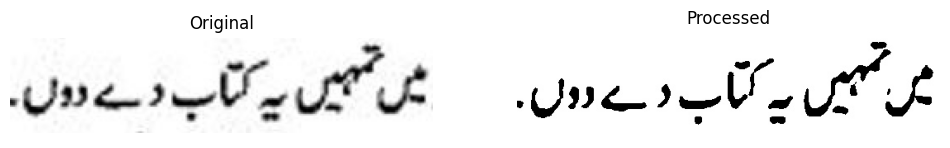

In [17]:
import matplotlib.pyplot as plt

# Pick one example - adjust index/filename as needed
sample_raw = all_images[14]  # change this number to check different images
sample_processed = os.path.join(processed_base,
    f"{os.path.basename(os.path.dirname(sample_raw)).replace(' ', '_')}_{os.path.basename(sample_raw)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.imread(sample_raw))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.imread(sample_processed), cmap='gray')
axes[1].set_title('Processed')
axes[1].axis('off')

plt.show()

In [19]:
folder_choice = 'Book'
folder_path = os.path.join(raw_base, folder_choice)
files_in_folder = sorted(os.listdir(folder_path))
print(files_in_folder[:10])  # show first 10 actual filenames

['1..JPG', '10..JPG', '11..JPG', '12..JPG', '13..JPG', '14..JPG', '15..JPG', '16..JPG', '17..JPG', '18..JPG']


Raw exists: True
Processed exists: True


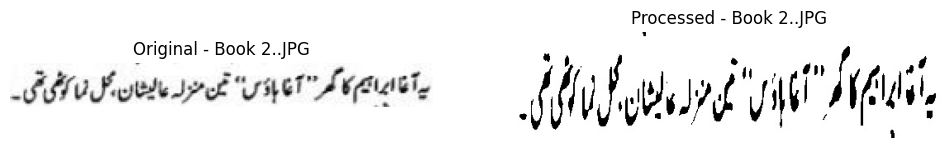

In [21]:
import matplotlib.pyplot as plt

folder_choice = 'Book'
image_filename = '2..JPG'   # copy exact name from the list, change to check different images

sample_raw = os.path.join(raw_base, folder_choice, image_filename)
sample_processed = os.path.join(processed_base, f"{folder_choice.replace(' ', '_')}_{image_filename}")

print('Raw exists:', os.path.exists(sample_raw))
print('Processed exists:', os.path.exists(sample_processed))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.imread(sample_raw))
axes[0].set_title(f'Original - {folder_choice} {image_filename}')
axes[0].axis('off')

axes[1].imshow(cv2.imread(sample_processed), cmap='gray')
axes[1].set_title(f'Processed - {folder_choice} {image_filename}')
axes[1].axis('off')

plt.show()

In [23]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize keeping aspect ratio, then pad to 512x128
    h, w = gray.shape
    target_w, target_h = 512, 128
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized_temp = cv2.resize(gray, (new_w, new_h))

    # Pad with white to reach exact target size
    canvas = np.full((target_h, target_w), 255, dtype=np.uint8)
    y_offset = (target_h - new_h) // 2
    x_offset = (target_w - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized_temp

    denoised = cv2.fastNlMeansDenoising(canvas, h=10)

    # Adaptive threshold instead of fixed value - handles varying contrast better
    binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)

    cv2.imwrite(save_path, binary)
    return binary

In [24]:
# Clear old processed folder first
import shutil
shutil.rmtree(processed_base)
os.makedirs(processed_base, exist_ok=True)

processed_count = 0
for img_path in all_images:
    folder_name = os.path.basename(os.path.dirname(img_path)).replace(' ', '_')
    filename = os.path.basename(img_path)
    save_path = os.path.join(processed_base, f'{folder_name}_{filename}')
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')

Done! Processed 112 images


Raw exists: True
Processed exists: True


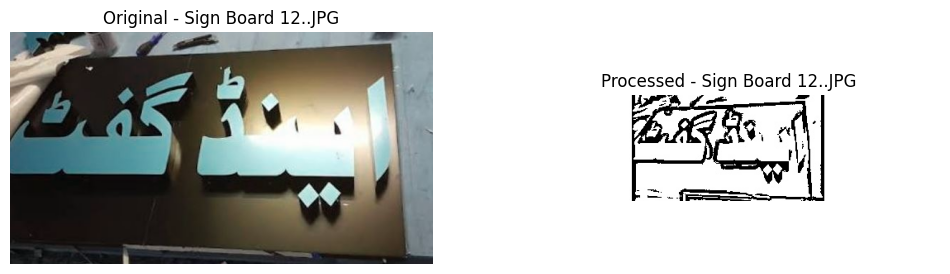

In [48]:
import matplotlib.pyplot as plt

folder_choice = 'Sign Board'
image_filename = '12..JPG'   # copy exact name from the list, change to check different images

sample_raw = os.path.join(raw_base, folder_choice, image_filename)
sample_processed = os.path.join(processed_base, f"{folder_choice.replace(' ', '_')}_{image_filename}")

print('Raw exists:', os.path.exists(sample_raw))
print('Processed exists:', os.path.exists(sample_processed))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.imread(sample_raw))
axes[0].set_title(f'Original - {folder_choice} {image_filename}')
axes[0].axis('off')

axes[1].imshow(cv2.imread(sample_processed), cmap='gray')
axes[1].set_title(f'Processed - {folder_choice} {image_filename}')
axes[1].axis('off')

plt.show()

In [1]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (6,721 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import pytesseract

raw_base = '/content/drive/MyDrive/urdu-ocr-si26/data/raw'
processed_base = '/content/drive/MyDrive/urdu-ocr-si26/data/processed'

print('Raw base exists:', os.path.exists(raw_base))
print('Processed base exists:', os.path.exists(processed_base))
print('Number of processed files:', len(os.listdir(processed_base)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw base exists: True
Processed base exists: True
Number of processed files: 112


In [6]:
test_images = list(glob.glob(f'{processed_base}/*.JPG'))[:5]
if not test_images:
    test_images = list(glob.glob(f'{processed_base}/*.jpg'))[:5]

print('=== Tesseract Results on Urdu Images ===')
print()

for img_path in test_images:
    img = Image.open(img_path)
    result = pytesseract.image_to_string(img, lang='urd')
    print(f'Image: {img_path}')
    print(f'Tesseract output: {result}')
    print('---')

=== Tesseract Results on Urdu Images ===

Image: /content/drive/MyDrive/urdu-ocr-si26/data/processed/Book_1..JPG
Tesseract output: ڈرخنے کاکردارا کہانی کان بھی جع نی تھا

---
Image: /content/drive/MyDrive/urdu-ocr-si26/data/processed/Book_2..JPG
Tesseract output: یآنااھاتکا اگھر' آھا ڈی شس منزلہ خالیشان بل ماک یی _

---
Image: /content/drive/MyDrive/urdu-ocr-si26/data/processed/Book_3..JPG
Tesseract output: ول یس ای کفکا نا سا چھا۔

---
Image: /content/drive/MyDrive/urdu-ocr-si26/data/processed/Book_4..JPG
Tesseract output: من یقاب سس گی ے؟+“

---
Image: /content/drive/MyDrive/urdu-ocr-si26/data/processed/Book_5..JPG
Tesseract output: دہ جیائے ہ- لت خاموق سے!سے ‏ تا ۸

---


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/urdu-ocr-si26/data/labels.csv', encoding='utf-8')

# Match the 5 test images back to their labels
for img_path in test_images:
    filename = os.path.basename(img_path)
    # Remove the folder prefix we added (e.g. "Book_1..JPG" -> need to find "Book/1..JPG")
    original_name = filename.replace('Book_', 'Book/', 1) if filename.startswith('Book_') else filename
    match = df[df['image'] == original_name]
    if not match.empty:
        print(f'{filename}: {match.iloc[0]["text"]}')
    else:
        print(f'{filename}: NOT FOUND in labels — check naming')

Book_1..JPG: فرشتے کا کردار اس کہانی کا کبھی بھی حصہ نہیں تھا
Book_2..JPG: یہ آغا ابراہیم کا گھر "آغا ہاؤس" تین منزلہ عالیشان محل نما کوٹھی تھی۔
Book_3..JPG: دل میں ایک کانٹا سا چبھا۔
Book_4..JPG: "یہ کتاب کس کی ہے؟"
Book_5..JPG: وہ چائے کے سپ لیتا خاموشی سے اسے دیکھتا رہا۔


## Why We Need a Better Model

**Test 1**
- Actual: فرشتے کا کردار اس کہانی کا کبھی بھی حصہ نہیں تھا
- Tesseract: ڈرخنے کاکردارا کہانی کان بھی جع نی تھا
- Issue: Wrong first word entirely, missing spaces between several words, "نہیں" dropped to "نی"

**Test 2**
- Actual: یہ آغا ابراہیم کا گھر "آغا ہاؤس" تین منزلہ عالیشان محل نما کوٹھی تھی۔
- Tesseract: یآنااھاتکا اگھر' آھا ڈی شس منزلہ خالیشان بل ماک یی
- Issue: Heavy word-merging, "عالیشان" misread as "خالیشان", large chunks dropped or replaced with gibberish

**Test 3**
- Actual: دل میں ایک کانٹا سا چبھا۔
- Tesseract: ول یس ای کفکا نا سا چھا۔
- Issue: "دل" misread as "ول", "میں" garbled to "یس ای", "کانٹا" corrupted to "کفکا"

**Test 4**
- Actual: "یہ کتاب کس کی ہے؟"
- Tesseract: من یقاب سس گی ے؟"
- Issue: Almost entirely different characters, barely resembles original

**Test 5**
- Actual: وہ چائے کے سپ لیتا خاموشی سے اسے دیکھتا رہا۔
- Tesseract: دہ جیائے ہ- لت خاموق سے!سے تا ۸
- Issue: "وہ" misread as "دہ", "خاموشی" corrupted to "خاموق", ending garbled into stray symbols and a number

**Summary**

**Tesseract fails on Urdu because** it struggles to correctly segment and recognize Urdu's cursive, context-dependent letterforms, where each letter changes shape depending on its position within a word. Across all 5 test images, Tesseract consistently merged separate words together, substituted visually similar but incorrect characters, and in several cases produced text that barely resembled the original sentence at all. Even after preprocessing (grayscale, resizing, denoising, and adaptive binarization), Tesseract's accuracy remained poor, showing that the core issue lies in its underlying Urdu language model rather than image quality. This confirms that general-purpose OCR engines like Tesseract built primarily for Latin scripts are not reliable for Urdu without a dedicated, custom-trained model, which is exactly the problem this project sets out to solve.